# Exercise: [Julia Set](https://en.wikipedia.org/wiki/Julia_set)

**Note: You should use 8 Julia threads for this exercise. Select the Jupyter kernel `Julia (8 threads) 1.10.0`.**

In [1]:
using Base.Threads
@assert Threads.nthreads() == 8

<img src="juliaset.svg" width=700>

In this exercise we want to compute an image of the [Julia set](https://en.wikipedia.org/wiki/Julia_set) (see above) first sequentially and then in parallel using different **multithreading** variants.

The value of a single pixel (`i,j` coordinates) of the Julia set, which corresponds to a point `z` in the complex number plane, can be computed by the following iteration procedure / function.

In [2]:
function _compute_pixel(i, j, n; max_iter=255, c=-0.79 + 0.15 * im)
    x = -2.0 + (j - 1) * 4.0 / (n - 1)
    y = -2.0 + (i - 1) * 4.0 / (n - 1)

    z = x + y * im
    iter = max_iter
    for k in 1:max_iter
        if abs2(z) > 4.0
            iter = k - 1
            break
        end
        z = z^2 + c
    end
    return iter
end

_compute_pixel (generic function with 1 method)

Note that the value of the pixel is the number of performed iterations for the corresponding complex number `z`.

In [3]:
using Plots
using BenchmarkTools

**Task 1:** Utilizing the function `_compute_pixel!(i,j,n)` from above, implement a function `compute_juliaset_sequential!(img)` below and verify (by plotting) that you actually get the desired Julia set image
* Hint 1: `img` is a two-dimensional array with equal size in each dimension. Essentially you just have to loop over both dimensions and fill the `img` array.
* Hint 2: use `@inbounds` if you like.

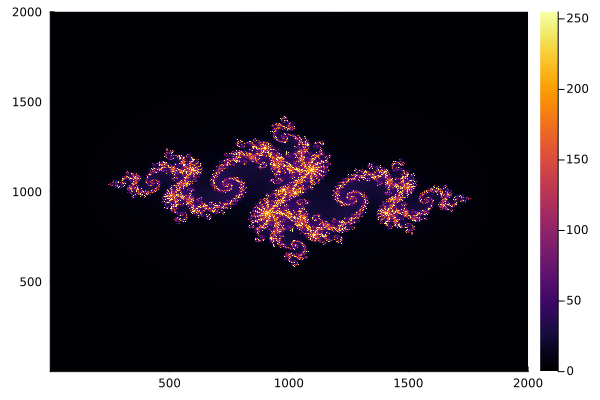

In [4]:
"""
Computes the Julia set sequentially (column by column).
The result is written into `img`.
"""
function compute_juliaset_sequential!(img)
    N = size(img, 1)
    #
    # TODO...
    #
    for j in 1:N
        for i in 1:N
            @inbounds img[i, j] = _compute_pixel(i, j, N)
        end
    end
    return img
end

N = 2000
img = zeros(Int, N, N)
compute_juliaset_sequential!(img)
heatmap(img)

**Task 2:** Now implement a variant `compute_juliaset_threads!` that does the same as `compute_juliaset_sequential` but that parallelizes the outer loop (that iterates over columns) via `@threads`.

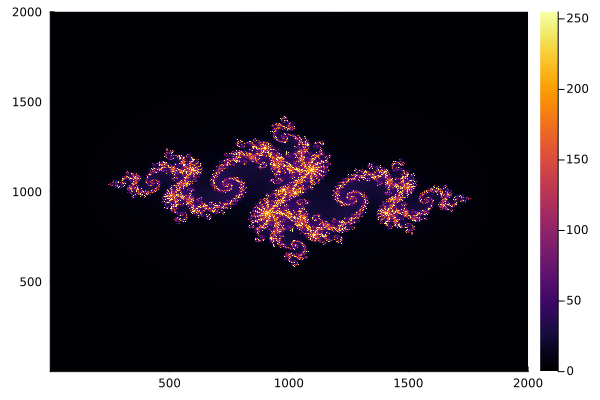

In [5]:
"""
Computes the Julia set column by column using multithreading (`@threads`).
The result is written into `img`.
"""
function compute_juliaset_threads!(img)
    N = size(img, 1)
    #
    # TODO...
    #
    @threads for j in 1:N
        for i in 1:N
            @inbounds img[i, j] = _compute_pixel(i, j, N)
        end
    end
    return img
end

N = 2000
img = zeros(Int, N, N)
compute_juliaset_threads!(img)
heatmap(img)

**Task 3:** Now implement a variant `compute_juliaset_spawn!` that uses `@spawn` to multithread the computation. (Note: Don't forget to synchronize with `@sync`!)

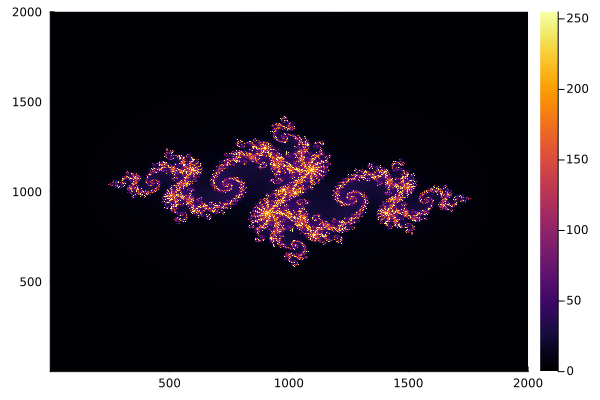

In [6]:
"""
Computes the Julia set column by column using multithreading (`@spawn`).
The result is written into `img`.
"""
function compute_juliaset_spawn!(img)
    N = size(img, 1)
    #
    # TODO...
    #
    @sync for j in 1:N
        @spawn begin
            for i in 1:N
                @inbounds img[i, j] = _compute_pixel(i, j, N)
            end
        end
    end
    return img
end

N = 2000
img = zeros(Int, N, N)
compute_juliaset_spawn!(img)
heatmap(img)

**Task 4:** Benchmark the three variants. Can you explain why the `@spawn` variant is faster than the version with `@threads`?

In [7]:
# 4)
N = 2000
img = zeros(Int, N, N)
#
# TODO...
#
@btime compute_juliaset_sequential!($img) samples = 5 evals = 3;
@btime compute_juliaset_threads!($img) samples = 5 evals = 3;
@btime compute_juliaset_spawn!($img) samples = 5 evals = 3;

  138.075 ms (0 allocations: 0 bytes)
  35.035 ms (41 allocations: 4.24 KiB)
  18.900 ms (10014 allocations: 1.03 MiB)


**Explanation:**

The key point is that the number of iterations per pixel (or column),
and hence the computational cost, varies for different input points.
The workload across the entire image is therefore **non-uniform**
and can benefit from **load-balancing**.
While `@threads` divides the work (close to) equally among threads
`@spawn` gives a form of load-balancing and is thus the fastest.